In [2]:
# ============================================================
# Cell 1 — Imports
# ============================================================
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
from pathlib import Path

In [3]:
# ============================================================
# Cell 2 — Dataset path configuration
# ============================================================

# Path relative to the notebooks/ folder
DATASET_PATH = Path("../data/raw/Dataset")

# Verify the path exists
if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {DATASET_PATH.resolve()}\n"
        "Make sure your folder is: data/raw/Dataset/"
    )

print(f"✅ Dataset found at: {DATASET_PATH.resolve()}")

✅ Dataset found at: D:\industrial-system-monitoring-ml\data\raw\Dataset


In [4]:
# ============================================================
# Cell 3 — Discover class names from folder names
# ============================================================

CLASS_NAMES = sorted([
    d.name for d in DATASET_PATH.iterdir() if d.is_dir()
])

print(f"Number of classes : {len(CLASS_NAMES)}")
print(f"Class names       :")
for i, cls in enumerate(CLASS_NAMES):
    print(f"  [{i}] {cls}")

Number of classes : 9
Class names       :
  [0] Broken stitch
  [1] Needle mark
  [2] Pinched fabric
  [3] Vertical
  [4] defect free
  [5] hole
  [6] horizontal
  [7] lines
  [8] stain


In [5]:
# ============================================================
# Cell 4 — Count images per class
# ============================================================

def count_images_per_class(dataset_path: Path, class_names: list) -> dict:
    """
    Counts image files per class folder.
    Supports .jpg, .jpeg, .png, .bmp formats.
    """
    valid_extensions = {".jpg", ".jpeg", ".png", ".bmp"}
    counts = {}

    for cls in class_names:
        cls_folder = dataset_path / cls
        images = [
            f for f in cls_folder.iterdir()
            if f.suffix.lower() in valid_extensions
        ]
        counts[cls] = len(images)

    return counts

class_counts = count_images_per_class(DATASET_PATH, CLASS_NAMES)

print("Images per class:")
print("-" * 40)
for cls, count in class_counts.items():
    bar = "█" * (count // 30)  # simple ASCII bar
    print(f"  {cls:<20} : {count:>4}  {bar}")
print("-" * 40)
print(f"  {'TOTAL':<20} : {sum(class_counts.values())}")

Images per class:
----------------------------------------
  Broken stitch        :  112  ███
  Needle mark          :  108  ███
  Pinched fabric       :  108  ███
  Vertical             :  101  ███
  defect free          : 1666  ███████████████████████████████████████████████████████
  hole                 :  281  █████████
  horizontal           :  136  ████
  lines                :  157  █████
  stain                :  398  █████████████
----------------------------------------
  TOTAL                : 3067


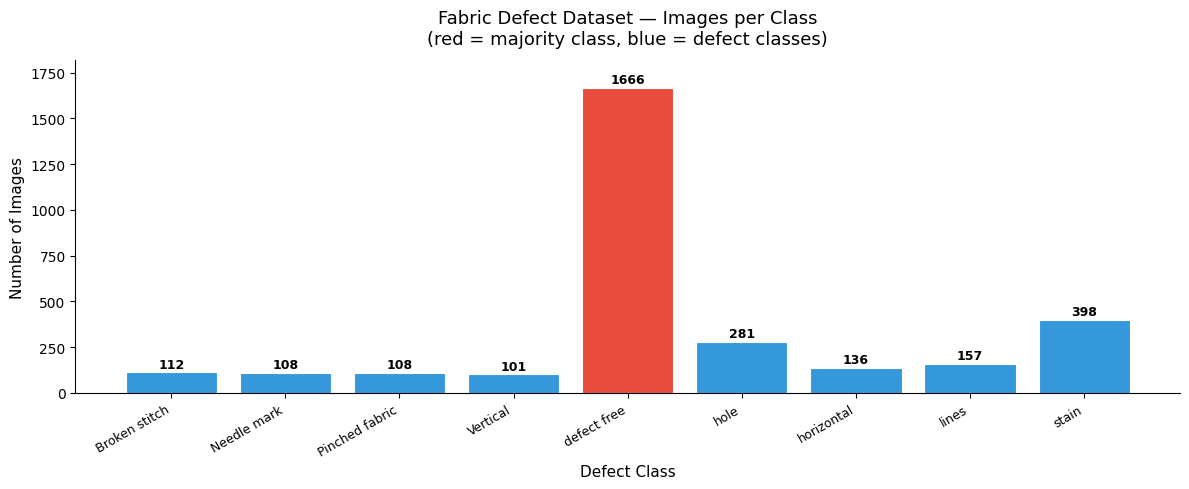

In [6]:
# ============================================================
# Cell 5 — Bar chart: class distribution (shows imbalance!)
# ============================================================

def plot_class_distribution(class_counts: dict):
    """
    Bar chart of images per class.
    The 'defect free' class will clearly stand out — 
    this imbalance will be handled in preprocessing.
    """
    fig, ax = plt.subplots(figsize=(12, 5))

    classes = list(class_counts.keys())
    counts  = list(class_counts.values())

    # Color defect-free differently to highlight imbalance
    colors = [
        "#e74c3c" if cls == "defect free" else "#3498db"
        for cls in classes
    ]

    bars = ax.bar(classes, counts, color=colors, edgecolor="white", linewidth=0.8)

    # Annotate each bar with its count
    for bar, count in zip(bars, counts):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 10,
            str(count),
            ha="center", va="bottom", fontsize=9, fontweight="bold"
        )

    ax.set_title(
        "Fabric Defect Dataset — Images per Class\n"
        "(red = majority class, blue = defect classes)",
        fontsize=13, pad=12
    )
    ax.set_xlabel("Defect Class", fontsize=11)
    ax.set_ylabel("Number of Images", fontsize=11)
    ax.set_ylim(0, max(counts) + 150)
    plt.xticks(rotation=30, ha="right", fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()

plot_class_distribution(class_counts)

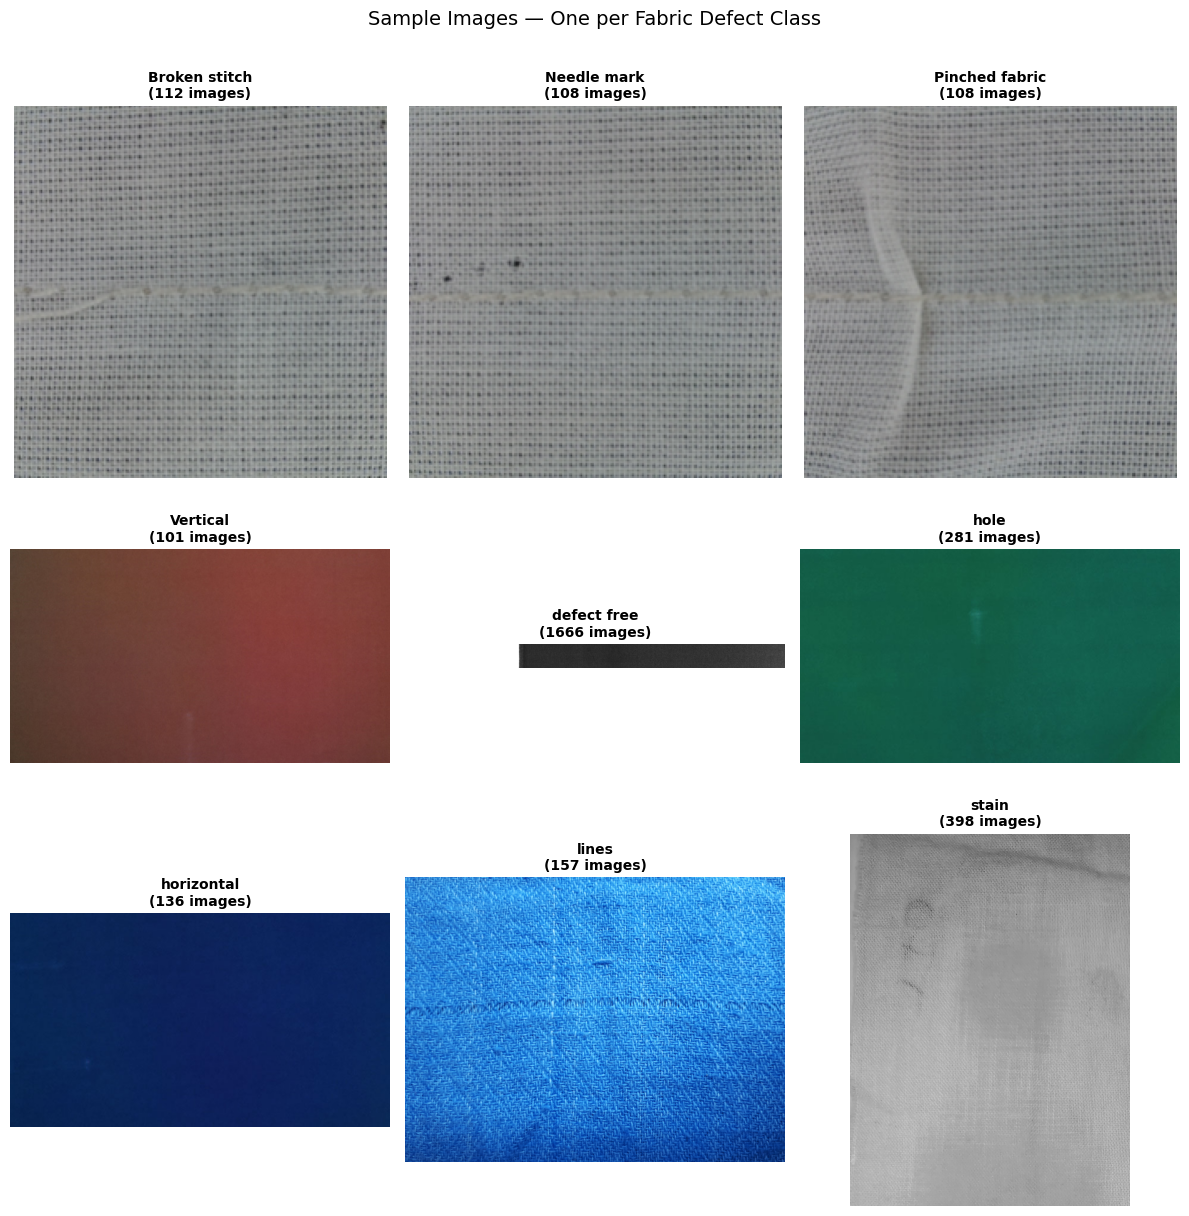

In [7]:
# ============================================================
# Cell 6 — Display one sample image per class (3 columns)
# ============================================================

def show_sample_images(dataset_path: Path, class_names: list, cols: int = 3):
    """
    Shows one sample image per class in a grid.
    Helps visually confirm images loaded correctly.
    """
    valid_extensions = {".jpg", ".jpeg", ".png", ".bmp"}
    rows = (len(class_names) + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    axes = axes.flatten()

    for idx, cls in enumerate(class_names):
        cls_folder = dataset_path / cls
        images = [
            f for f in cls_folder.iterdir()
            if f.suffix.lower() in valid_extensions
        ]

        if not images:
            axes[idx].axis("off")
            continue

        img = mpimg.imread(str(images[0]))
        axes[idx].imshow(img, cmap="gray" if img.ndim == 2 else None)
        axes[idx].set_title(
            f"{cls}\n({len(images)} images)",
            fontsize=10, fontweight="bold"
        )
        axes[idx].axis("off")

    # Turn off any unused subplot slots
    for idx in range(len(class_names), len(axes)):
        axes[idx].axis("off")

    fig.suptitle(
        "Sample Images — One per Fabric Defect Class",
        fontsize=14, y=1.01
    )
    plt.tight_layout()
    plt.show()

show_sample_images(DATASET_PATH, CLASS_NAMES)

In [8]:
# ============================================================
# Cell 7 — Inspect one image's properties
# ============================================================

def inspect_image(dataset_path: Path, class_name: str):
    """
    Prints shape, dtype, and pixel range for one sample image.
    This tells us what transforms we'll need in preprocessing.
    """
    valid_extensions = {".jpg", ".jpeg", ".png", ".bmp"}
    cls_folder = dataset_path / class_name

    sample = next(
        f for f in cls_folder.iterdir()
        if f.suffix.lower() in valid_extensions
    )

    img = mpimg.imread(str(sample))

    print(f"Sample from class : '{class_name}'")
    print(f"File              : {sample.name}")
    print(f"Shape             : {img.shape}  ← (H, W, C) or (H, W) if grayscale")
    print(f"Dtype             : {img.dtype}")
    print(f"Pixel range       : [{img.min()}, {img.max()}]")

# Inspect one class — change class name as needed
inspect_image(DATASET_PATH, CLASS_NAMES[0])

Sample from class : 'Broken stitch'
File              : A_02_001.jpg
Shape             : (224, 224, 3)  ← (H, W, C) or (H, W) if grayscale
Dtype             : uint8
Pixel range       : [49, 174]


In [9]:
# ============================================================
# Cell 8 — EDA Summary
# ============================================================

total = sum(class_counts.values())
majority = max(class_counts, key=class_counts.get)
minority = min(class_counts, key=class_counts.get)

print("=" * 50)
print("    FABRIC DEFECT DATASET — EDA SUMMARY")
print("=" * 50)
print(f"  Total classes     : {len(CLASS_NAMES)}")
print(f"  Total images      : {total}")
print(f"  Majority class    : '{majority}' ({class_counts[majority]} images) ⚠️")
print(f"  Minority class    : '{minority}' ({class_counts[minority]} images)")
print(f"  Imbalance ratio   : {class_counts[majority] / class_counts[minority]:.1f}x")
print("=" * 50)
print("\n  ⚠️  Class imbalance detected!")
print("  → Will use WeightedRandomSampler in Phase 2")
print("  → Will use class_weight in loss function")
print("\n  ✅ Ready for Phase 2 → Preprocessing")

    FABRIC DEFECT DATASET — EDA SUMMARY
  Total classes     : 9
  Total images      : 3067
  Majority class    : 'defect free' (1666 images) ⚠️
  Minority class    : 'Vertical' (101 images)
  Imbalance ratio   : 16.5x

  ⚠️  Class imbalance detected!
  → Will use WeightedRandomSampler in Phase 2
  → Will use class_weight in loss function

  ✅ Ready for Phase 2 → Preprocessing
